# Capstone Two: Data Wrangling
## Class A/B/C Multifamily Risk Score in USA

Daksha Gummadi

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [47]:
# Load ZORI metro rent data
zori = pd.read_csv('ZORI.csv')
print(zori.shape)
zori.head()

(544, 137)


,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
0,102001,0,United States,country,NaN,1133.731984,1140.842483,1151.491726,1160.033277,1169.166164,...,1741.991065,1752.625204,1760.157451,1764.336689,1765.122255,1763.668003,1759.999943,1754.196322,1746.749782,1741.252791
1,394913,1,"New York, NY",msa,NY,2138.171808,2150.760266,2168.721822,2189.520988,2208.135902,...,3094.573944,3124.006867,3150.263404,3181.819213,3212.506185,3234.750295,3231.961016,3218.066769,3192.622168,3178.930447
2,753899,2,"Los Angeles, CA",msa,CA,1650.480148,1663.198362,1679.338522,1697.632972,1711.599397,...,2646.787779,2652.945031,2658.214796,2663.500267,2664.673610,2665.921498,2665.460541,2664.282373,2655.906124,2646.376452
3,394463,3,"Chicago, IL",msa,IL,1304.813747,1311.902202,1321.136646,1328.459786,1338.305502,...,1909.200625,1932.860943,1952.495911,1971.280014,1979.364323,1981.099793,1976.849190,1970.494752,1965.523589,1962.269835
4,394514,4,"Dallas, TX",msa,TX,1022.032360,1015.534937,1021.449858,1039.959308,1051.707029,...,1510.271466,1520.176097,1522.803851,1522.471741,1517.940631,1514.210173,1508.431221,1501.215235,1494.662312,1490.557604


In [33]:
# Load vacancy rate
vacancy = pd.read_csv('RRVRUSQ156N.csv')
vacancy = vacancy.rename(columns={'observation_date':'date', 'RRVRUSQ156N':'vacancy_rate'})
vacancy['date'] = pd.to_datetime(vacancy['date'])
print(vacancy.shape)
vacancy.head()

(24, 2)


,date,vacancy_rate
0,2020-01-01,6.6
1,2020-04-01,5.7
2,2020-07-01,6.4
3,2020-10-01,6.5
4,2021-01-01,6.8


In [35]:
# Load building permits
permits = pd.read_csv('PERMIT.csv')
permits = permits.rename(columns={'observation_date':'date', 'PERMIT':'permits'})
permits['date'] = pd.to_datetime(permits['date'])
print(permits.shape)
permits.head()

(70, 2)


,date,permits
0,2020-01-01,1495
1,2020-02-01,1455
2,2020-03-01,1346
3,2020-04-01,1076
4,2020-05-01,1250


In [49]:
#reshape zori wide to long format
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
date_cols = [col for col in zori.columns if col not in id_cols]

zori_long = pd.melt(zori, id_vars=id_cols, value_vars=date_cols, 
                    var_name='date', value_name='rent')
zori_long['date'] = pd.to_datetime(zori_long['date'])

#filter to 2020 onwards
zori_long = zori_long[zori_long['date'] >= '2020-01-01']

#drop missing values
zori_long = zori_long.dropna(subset=['rent'])

print(zori_long.shape)
zori_long.head()

(23822, 7)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,rent
32640,102001,0,United States,country,NaN,2020-01-31,1366.790675
32641,394913,1,"New York, NY",msa,NY,2020-01-31,2428.816367
32642,753899,2,"Los Angeles, CA",msa,CA,2020-01-31,2179.929265
32643,394463,3,"Chicago, IL",msa,IL,2020-01-31,1485.127590
32644,394514,4,"Dallas, TX",msa,TX,2020-01-31,1257.340995


In [51]:
#calculate & create national average rent by month
national_rent = zori_long.groupby('date')['rent'].mean().reset_index()
national_rent.columns = ['date', 'avg_rent']
print(national_rent.shape)
national_rent.head(10)

(72, 2)


,date,avg_rent
0,2020-01-31,1144.559911
1,2020-02-29,1150.840542
2,2020-03-31,1157.791469
3,2020-04-30,1155.929327
4,2020-05-31,1154.101083
5,2020-06-30,1155.181646
6,2020-07-31,1160.741194
7,2020-08-31,1144.482299
8,2020-09-30,1155.257865
9,2020-10-31,1165.048501


In [41]:
#create monthly date range and convert quarterly vacancy to monthly
date_range = pd.date_range(start=vacancy['date'].min(), 
                           end=vacancy['date'].max(), freq='MS')
monthly_dates = pd.DataFrame({'date': date_range})

#merge and interpolate
vacancy_monthly = monthly_dates.merge(vacancy, on='date', how='left')
vacancy_monthly['vacancy_rate'] = vacancy_monthly['vacancy_rate'].interpolate()

print(vacancy_monthly.shape)
vacancy_monthly.head(10)

(70, 2)


,date,vacancy_rate
0,2020-01-01,6.600000
1,2020-02-01,6.300000
2,2020-03-01,6.000000
3,2020-04-01,5.700000
4,2020-05-01,5.933333
5,2020-06-01,6.166667
6,2020-07-01,6.400000
7,2020-08-01,6.433333
8,2020-09-01,6.466667
9,2020-10-01,6.500000


## Merge all data

In [53]:
#merges all data below

#merge national rent with vacancy
df = national_rent.merge(vacancy_monthly, on='date', how='left')

#merge with permits
df = df.merge(permits, on='date', how='left')

#sort by date
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
df.head(10)

(72, 4)


,date,avg_rent,vacancy_rate,permits
0,2020-01-31,1144.559911,NaN,NaN
1,2020-02-29,1150.840542,NaN,NaN
2,2020-03-31,1157.791469,NaN,NaN
3,2020-04-30,1155.929327,NaN,NaN
4,2020-05-31,1154.101083,NaN,NaN
5,2020-06-30,1155.181646,NaN,NaN
6,2020-07-31,1160.741194,NaN,NaN
7,2020-08-31,1144.482299,NaN,NaN
8,2020-09-30,1155.257865,NaN,NaN
9,2020-10-31,1165.048501,NaN,NaN


In [55]:
# calculates year over year rent growth
df['rent_growth_yoy'] = ((df['avg_rent'] - df['avg_rent'].shift(12)) / df['avg_rent'].shift(12)) * 100

print(df[['date', 'avg_rent', 'rent_growth_yoy']].tail(20))

         date     avg_rent  rent_growth_yoy
52 2024-05-31  1343.164152         1.559680
53 2024-06-30  1350.891488         1.668479
54 2024-07-31  1351.275819         1.351035
55 2024-08-31  1355.097899         1.407978
56 2024-09-30  1355.866181         1.886463
57 2024-10-31  1353.612763         2.107639
58 2024-11-30  1350.436067         2.175971
59 2024-12-31  1351.904493         2.417276
60 2025-01-31  1348.113123         2.057969
61 2025-02-28  1356.515694         2.770090
62 2025-03-31  1355.376008         1.925977
63 2025-04-30  1361.884909         2.052803
64 2025-05-31  1366.753558         1.756256
65 2025-06-30  1370.295198         1.436363
66 2025-07-31  1365.321191         1.039416
67 2025-08-31  1368.015698         0.953274
68 2025-09-30  1368.701149         0.946625
69 2025-10-31  1359.861725         0.461651
70 2025-11-30  1350.757262         0.023785
71 2025-12-31  1328.643619        -1.720600


In [57]:
#classify metros by rent percentiles for each month also known as property class segments
def classify_class(group):
    q75 = group['rent'].quantile(0.75)
    q25 = group['rent'].quantile(0.25)
    group['class'] = 'Class_B'
    group.loc[group['rent'] >= q75, 'class'] = 'Class_A'
    group.loc[group['rent'] <= q25, 'class'] = 'Class_C'
    return group

zori_class = zori_long.groupby('date', group_keys=False).apply(classify_class)

print(zori_class['class'].value_counts())
zori_class.head(20)

class
Class_B    11848
Class_A     5987
Class_C     5987
Name: count, dtype: int64


/var/folders/mn/fck54vbn351c64k3dr5v6r8w0000gn/T/ipykernel_12316/537487805.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zori_class = zori_long.groupby('date', group_keys=False).apply(classify_class)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,rent,class
32640,102001,0,United States,country,NaN,2020-01-31,1366.790675,Class_A
32641,394913,1,"New York, NY",msa,NY,2020-01-31,2428.816367,Class_A
32642,753899,2,"Los Angeles, CA",msa,CA,2020-01-31,2179.929265,Class_A
32643,394463,3,"Chicago, IL",msa,IL,2020-01-31,1485.127590,Class_A
32644,394514,4,"Dallas, TX",msa,TX,2020-01-31,1257.340995,Class_B
32645,394692,5,"Houston, TX",msa,TX,2020-01-31,1240.119046,Class_B
32646,395209,6,"Washington, DC",msa,VA,2020-01-31,1929.814220,Class_A
32647,394974,7,"Philadelphia, PA",msa,PA,2020-01-31,1405.858756,Class_A
32648,394856,8,"Miami, FL",msa,FL,2020-01-31,1674.771759,Class_A
32649,394347,9,"Atlanta, GA",msa,GA,2020-01-31,1339.326667,Class_A


In [59]:
# calculates average rent by class and date
class_avg = zori_class.groupby(['date', 'class'])['rent'].mean().reset_index()
class_pivot = class_avg.pivot(index='date', columns='class', values='rent').reset_index()
class_pivot.columns = ['date', 'rent_class_a', 'rent_class_b', 'rent_class_c']

print(class_pivot.shape)
class_pivot.head()

(72, 4)


,date,rent_class_a,rent_class_b,rent_class_c
0,2020-01-31,1652.213252,1076.384644,773.257105
1,2020-02-29,1660.939300,1083.146596,776.129677
2,2020-03-31,1666.230657,1091.209584,782.516050
3,2020-04-30,1653.767831,1090.998773,784.205937
4,2020-05-31,1643.310542,1091.453494,786.572517


In [61]:
#merges class data into main dataframe
df = df.merge(class_pivot, on='date', how='left')
print(df.shape)
df.head()

(72, 8)


,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c
0,2020-01-31,1144.559911,NaN,NaN,NaN,1652.213252,1076.384644,773.257105
1,2020-02-29,1150.840542,NaN,NaN,NaN,1660.939300,1083.146596,776.129677
2,2020-03-31,1157.791469,NaN,NaN,NaN,1666.230657,1091.209584,782.516050
3,2020-04-30,1155.929327,NaN,NaN,NaN,1653.767831,1090.998773,784.205937
4,2020-05-31,1154.101083,NaN,NaN,NaN,1643.310542,1091.453494,786.572517


In [63]:
#calculates class specific growth rates
df['growth_class_a'] = ((df['rent_class_a'] - df['rent_class_a'].shift(12)) / df['rent_class_a'].shift(12)) * 100
df['growth_class_b'] = ((df['rent_class_b'] - df['rent_class_b'].shift(12)) / df['rent_class_b'].shift(12)) * 100
df['growth_class_c'] = ((df['rent_class_c'] - df['rent_class_c'].shift(12)) / df['rent_class_c'].shift(12)) * 100

print(df[['date', 'growth_class_a', 'growth_class_b', 'growth_class_c']].tail(20))

         date  growth_class_a  growth_class_b  growth_class_c
52 2024-05-31        2.066170        1.146522        1.642848
53 2024-06-30        2.001749        1.356072        1.936176
54 2024-07-31        1.594689        0.899880        2.036764
55 2024-08-31        1.610153        0.975007        2.132034
56 2024-09-30        2.012909        1.408538        2.990213
57 2024-10-31        2.294723        1.738558        2.769357
58 2024-11-30        2.449060        2.012225        2.140065
59 2024-12-31        2.317017        2.255973        3.262741
60 2025-01-31        2.592549        1.774052        1.883245
61 2025-02-28        3.346084        2.217703        2.926270
62 2025-03-31        2.210763        1.854881        1.606911
63 2025-04-30        2.270844        1.983052        1.695450
64 2025-05-31        1.744013        1.678378        1.860568
65 2025-06-30        1.663116        1.236348        1.602575
66 2025-07-31        1.161598        1.076672        0.700894
67 2025-

In [65]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

print(df[['date', 'year', 'month', 'quarter']].head())

#above adds time features

        date  year  month  quarter
0 2020-01-31  2020      1        1
1 2020-02-29  2020      2        1
2 2020-03-31  2020      3        1
3 2020-04-30  2020      4        2
4 2020-05-31  2020      5        2


In [67]:
yearly_avg = df.groupby('year').mean(numeric_only=True)
print(yearly_avg[['avg_rent', 'rent_growth_yoy', 'vacancy_rate', 'permits']])

# summary statistics by year

         avg_rent  rent_growth_yoy  vacancy_rate  permits
year                                                     
2020  1155.361905              NaN           NaN      NaN
2021  1231.747394         6.604063           NaN      NaN
2022  1316.873914         7.035751           NaN      NaN
2023  1323.012842         0.479056           NaN      NaN
2024  1343.115418         1.518153           NaN      NaN
2025  1358.353261         1.141967           NaN      NaN


In [69]:
class_summary = df[['rent_class_a', 'rent_class_b', 'rent_class_c', 
                    'growth_class_a', 'growth_class_b', 'growth_class_c']].describe()
print(class_summary)

#summary statistics by class

       rent_class_a  rent_class_b  rent_class_c  growth_class_a  \
count     72.000000     72.000000     72.000000       60.000000   
mean    1854.342766   1219.214683    858.017750        3.784972   
std      123.324911     69.828029     41.912168        4.897634   
min     1590.344387   1076.384644    773.257105       -1.371823   
25%     1767.701506   1184.027859    827.363880        0.330373   
50%     1905.379969   1248.899859    869.619372        1.987295   
75%     1946.398398   1270.310397    891.952145        5.514870   
max     1989.501435   1292.024104    915.474185       14.479924   

       growth_class_b  growth_class_c  
count       60.000000       60.000000  
mean         3.273173        2.750380  
std          3.800950        1.737837  
min         -1.795932       -2.253708  
25%          0.889948        1.605827  
50%          1.708468        2.525312  
75%          5.138135        3.859973  
max         11.724104        6.807779  


In [71]:
#checks missing values & duplicates
print(df.isnull().sum())

date                0
avg_rent            0
vacancy_rate       72
permits            72
rent_growth_yoy    12
rent_class_a        0
rent_class_b        0
rent_class_c        0
growth_class_a     12
growth_class_b     12
growth_class_c     12
year                0
month               0
quarter             0
dtype: int64


In [73]:
print(f"Duplicates: {df.duplicated(subset=['date']).sum()}")

Duplicates: 0


In [75]:
print("Rent range:", df['avg_rent'].min(), "to", df['avg_rent'].max())
print("Vacancy range:", df['vacancy_rate'].min(), "to", df['vacancy_rate'].max())
print("Permits range:", df['permits'].min(), "to", df['permits'].max())

Rent range: 1144.482299354305 to 1370.2951982643888
Vacancy range: nan to nan
Permits range: nan to nan


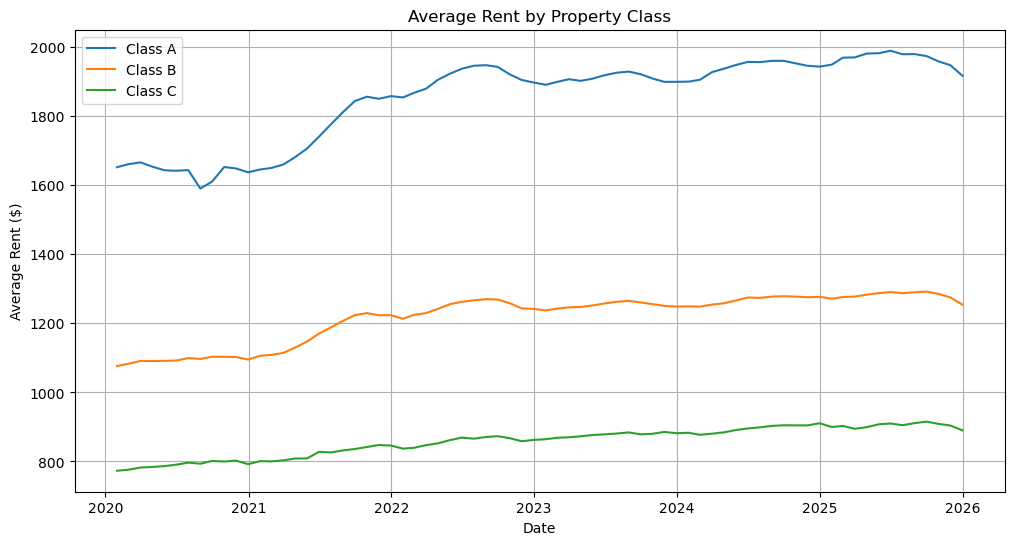

In [77]:
# visuals plot rent trends by class
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['rent_class_a'], label='Class A')
plt.plot(df['date'], df['rent_class_b'], label='Class B')
plt.plot(df['date'], df['rent_class_c'], label='Class C')
plt.xlabel('Date')
plt.ylabel('Average Rent ($)')
plt.title('Average Rent by Property Class')
plt.legend()
plt.grid(True)
plt.show()

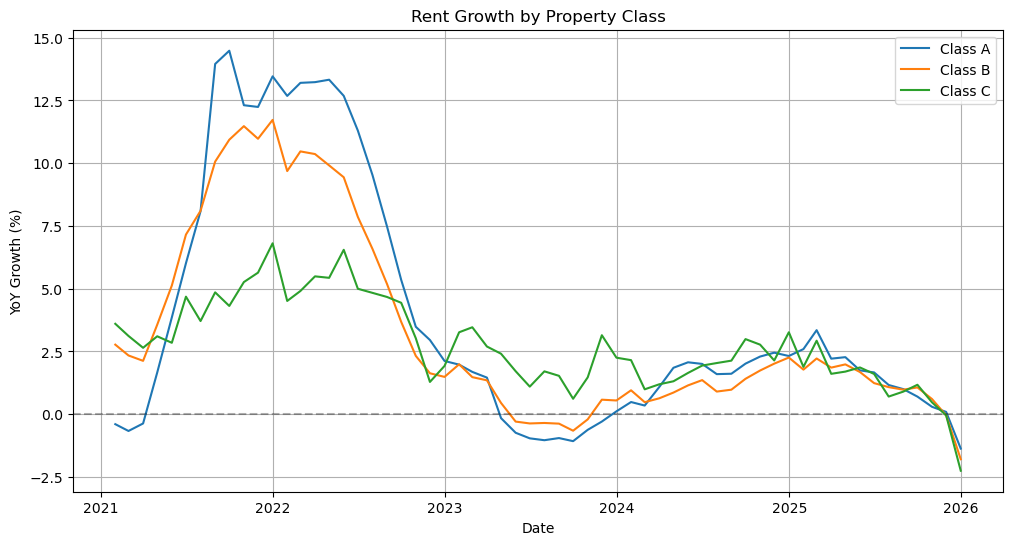

In [79]:
#visual: plot rent growth by class
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['growth_class_a'], label='Class A')
plt.plot(df['date'], df['growth_class_b'], label='Class B')
plt.plot(df['date'], df['growth_class_c'], label='Class C')
plt.xlabel('Date')
plt.ylabel('YoY Growth (%)')
plt.title('Rent Growth by Property Class')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.show()

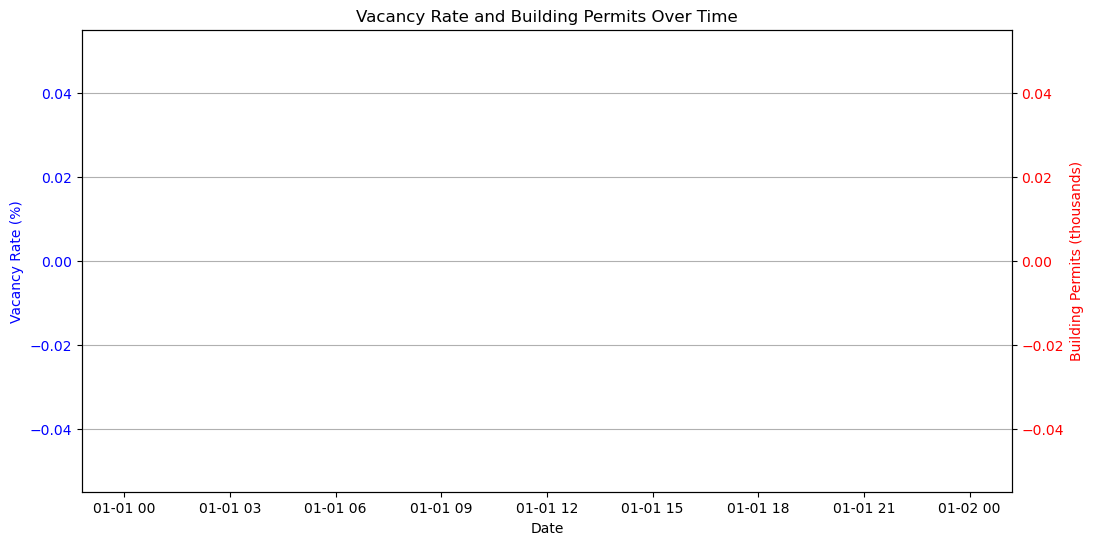

In [81]:
#plot vacancy rate and permits
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['date'], df['vacancy_rate'], 'b-', label='Vacancy Rate')
ax1.set_xlabel('Date')
ax1.set_ylabel('Vacancy Rate (%)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['permits'], 'r-', label='Building Permits')
ax2.set_ylabel('Building Permits (thousands)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Vacancy Rate and Building Permits Over Time')
plt.grid(True)
plt.show()

In [83]:
df.to_csv('master_dataset_cleaned.csv', index=False)
zori_class.to_csv('metro_data_with_classes.csv', index=False)
print("Data saved")

Data saved


In [85]:
print(df.info())
print("\nFinal shape:", df.shape)
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             72 non-null     datetime64[ns]
 1   avg_rent         72 non-null     float64       
 2   vacancy_rate     0 non-null      float64       
 3   permits          0 non-null      float64       
 4   rent_growth_yoy  60 non-null     float64       
 5   rent_class_a     72 non-null     float64       
 6   rent_class_b     72 non-null     float64       
 7   rent_class_c     72 non-null     float64       
 8   growth_class_a   60 non-null     float64       
 9   growth_class_b   60 non-null     float64       
 10  growth_class_c   60 non-null     float64       
 11  year             72 non-null     int32         
 12  month            72 non-null     int32         
 13  quarter          72 non-null     int32         
dtypes: datetime64[ns](1), float64(10), int32(3)


In [ ]:
df.head()

In [ ]:
df.tail()